# 강판 표면 결함 다중분류
### Random Forest — 기존 13개 피처 vs 전체 27개 피처 비교

이 노트북은 **같은 데이터 분할과 같은 Random Forest 설정**을 유지한 상태에서 피처 구성만 변경해 성능 차이를 비교한다.

- 비교 1: 기존 포트폴리오에서 사용한 13개 피처
- 비교 2: 타깃을 제외한 전체 27개 피처
- 비교 3: 전체 27개 중 자동 피처 선택 결과
- 주요 평가 지표: `Macro F1`

> 결론을 먼저 말하면, 이번 데이터에서는 일부 피처를 제거한 조합보다 **전체 27개 피처를 사용한 모델이 가장 높은 교차검증 Macro F1**을 기록했다.

**[1] 라이브러리 불러오기**

In [ ]:
# --------------------------------------------------
# 라이브러리
# --------------------------------------------------
from pathlib import Path
from functools import partial
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

N_JOBS = 1

**[2] 데이터 불러오기**

In [ ]:
# --------------------------------------------------
# 데이터 불러오기
# --------------------------------------------------
csv_candidates = [
    Path('./steel_plate_faults_multiclass.csv'),
    Path('./steel_plate_faults_multiclass(3).csv'),
    Path('/content/steel_plate_faults_multiclass.csv'),
    Path('/mnt/data/steel_plate_faults_multiclass(3).csv')
]

csv_path = next((path for path in csv_candidates if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError('CSV 파일 경로를 확인하세요.')

dataDF = pd.read_csv(csv_path)

print(f'[사용 파일] {csv_path}')
print(f'[전체 데이터 크기] {dataDF.shape}')
display(dataDF.head())

[사용 파일] /mnt/data/steel_plate_faults_multiclass(3).csv
[전체 데이터 크기] (1941, 28)


**[3] 데이터 품질과 클래스 분포 확인**

In [ ]:
# --------------------------------------------------
# 데이터 구조 및 품질 확인
# --------------------------------------------------
missing_count = dataDF.isnull().sum().sum()
duplicate_count = dataDF.duplicated().sum()
target_count = dataDF['Fault_Type'].value_counts()

print(f'[전체 결측치 개수] {missing_count}개')
print(f'[완전 중복 행 개수] {duplicate_count}개')
print('
[결함 유형별 데이터 개수]')
display(target_count.to_frame('count'))

[전체 결측치 개수] 0개
[완전 중복 행 개수] 0개

[결함 유형별 데이터 개수]


,count
Other_Faults,673
Bumps,402
K_Scatch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55


**[4] 비교할 피처 구성**

피처 효과만 비교하기 위해 모델 종류, 데이터 분할, 교차검증 방식은 동일하게 유지한다.

In [ ]:
# --------------------------------------------------
# 기존 13개 피처와 전체 27개 피처
# --------------------------------------------------
target_column = 'Fault_Type'

original_feature_columns = [
    'Length_of_Conveyer', 'Steel_Plate_Thickness',
    'Empty_Index', 'Square_Index', 'Edges_Index',
    'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index',
    'Edges_X_Index', 'Edges_Y_Index',
    'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter'
]

all_feature_columns = [
    column for column in dataDF.columns
    if column != target_column
]

print(f'기존 피처 수: {len(original_feature_columns)}개')
print(f'전체 피처 수: {len(all_feature_columns)}개')
print('
[전체 27개 피처]')
print(all_feature_columns)

기존 피처 수: 13개
전체 피처 수: 27개

[전체 27개 피처]
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']


**[5] Train/Test 분리**

In [ ]:
# --------------------------------------------------
# 학습 데이터와 테스트 데이터 분리
# --------------------------------------------------
X = dataDF[all_feature_columns].copy()
y = dataDF[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

X_train: (1552, 27), y_train: (1552,)
X_test : (389, 27), y_test : (389,)


**[6] 비교용 Random Forest 설정**

피처 구성만 공정하게 비교하기 위해 두 실험에 같은 하이퍼파라미터를 적용했다.

In [ ]:
# --------------------------------------------------
# 비교용 Random Forest 생성 함수
# --------------------------------------------------
def make_rf_model():
    return RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=N_JOBS
    )

skFold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

score = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

**[7] 기존 13개와 전체 27개 성능 비교**

In [ ]:
# --------------------------------------------------
# 피처 구성별 교차검증 및 테스트 평가
# --------------------------------------------------
feature_sets = {
    '기존 13개': original_feature_columns,
    '전체 27개': all_feature_columns
}

comparison_result = []

for feature_set_name, feature_columns in feature_sets.items():
    model = make_rf_model()

    cross_validation_result = cross_validate(
        model,
        X_train[feature_columns],
        y_train,
        cv=skFold,
        scoring=score,
        return_train_score=True,
        n_jobs=N_JOBS
    )

    model.fit(X_train[feature_columns], y_train)
    y_pred = model.predict(X_test[feature_columns])

    comparison_result.append({
        '피처 구성': feature_set_name,
        '피처 수': len(feature_columns),
        'CV Accuracy': cross_validation_result['test_accuracy'].mean(),
        'CV Macro F1': cross_validation_result['test_f1_macro'].mean(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Test Precision Macro': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Test Recall Macro': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Test F1 Weighted': f1_score(
            y_test, y_pred, average='weighted'
        )
    })

comparisonDF = pd.DataFrame(comparison_result)
display(comparisonDF.round(4))

,피처 구성,피처 수,CV Accuracy,CV Macro F1,Test Accuracy,Test Macro F1,Test Precision Macro,Test Recall Macro,Test F1 Weighted
0,기존 13개,13,0.7417,0.7610,0.7378,0.7548,0.7587,0.7545,0.7397
1,전체 27개,27,0.7745,0.7997,0.7995,0.8264,0.8558,0.8016,0.8020


### 비교 결과 해석

- 전체 27개 사용 시 CV Macro F1: **0.7997**
- 전체 27개 사용 시 Test Macro F1: **0.8264**
- 기존 13개 대비 Test Macro F1이 약 **0.0717** 상승
- 좌표, 밝기, 방향, 면적 관련 피처가 추가되면서 결함 유형을 구분할 정보가 늘어난 것으로 해석할 수 있다.

단, 테스트 점수만 보고 피처를 선택하지 않고 아래에서 **학습 데이터 내부의 교차검증 점수**로 피처 수를 결정한다.

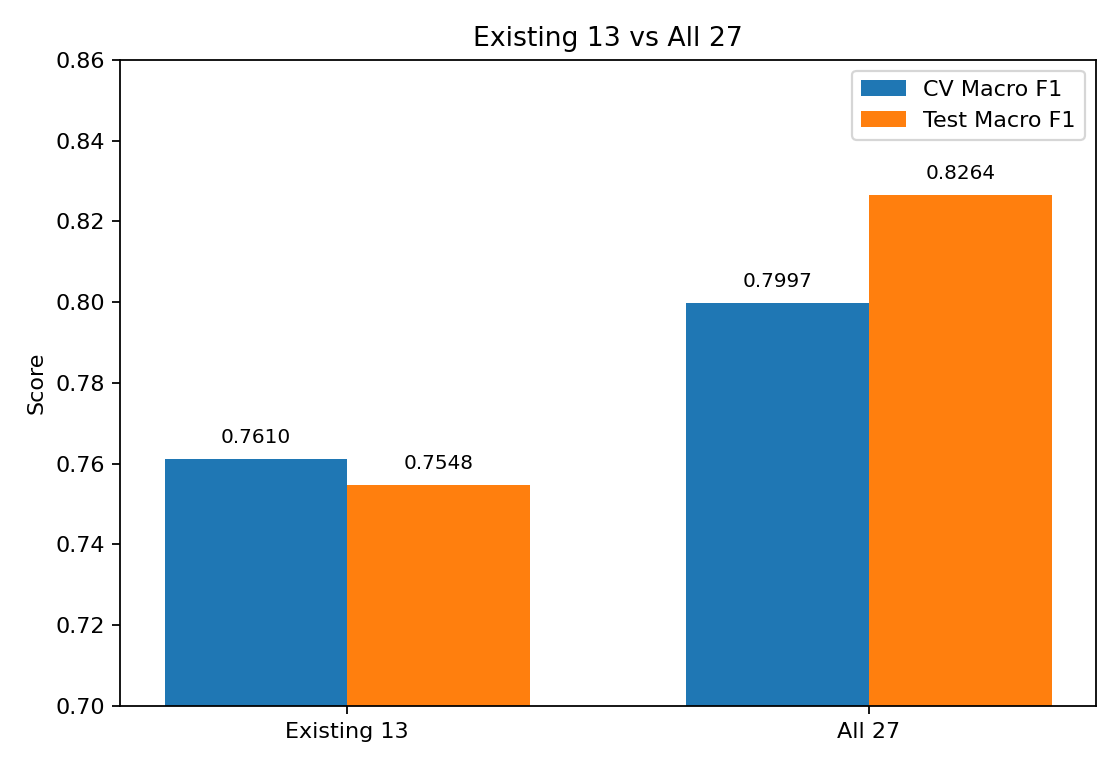

In [ ]:
# --------------------------------------------------
# 기존 13개와 전체 27개 성능 시각화
# --------------------------------------------------
x = np.arange(len(comparisonDF))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    comparisonDF['CV Macro F1'],
    width,
    label='CV Macro F1'
)
plt.bar(
    x + width / 2,
    comparisonDF['Test Macro F1'],
    width,
    label='Test Macro F1'
)

plt.xticks(x, comparisonDF['피처 구성'])
plt.ylabel('Score')
plt.ylim(0.70, 0.86)
plt.title('기존 13개 vs 전체 27개 피처')
plt.legend()
plt.tight_layout()
plt.show()

**[8] 자동 피처 수 선택**

`SelectKBest`가 학습 Fold 안에서 피처 점수를 계산하도록 Pipeline에 포함했다. 따라서 검증 Fold의 정보를 미리 사용하지 않는다.

- 후보 피처 수: 10, 15, 18, 21, 24, 전체 27개
- 선택 기준: Stratified 5-Fold의 평균 Macro F1
- 피처 점수: Mutual Information

In [ ]:
# --------------------------------------------------
# 피처 선택이 Fold 내부에서 수행되도록 Pipeline 구성
# --------------------------------------------------
def mutual_info_score(X_data, y_data):
    return mutual_info_classif(
        X_data,
        y_data,
        random_state=42
    )

selection_pipeline = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_score)),
    ('model', make_rf_model())
])

param_dict = {
    'select__k': [10, 15, 18, 21, 24, 'all']
}

searchModel = GridSearchCV(
    estimator=selection_pipeline,
    param_grid=param_dict,
    scoring='f1_macro',
    cv=skFold,
    refit=True,
    return_train_score=True,
    n_jobs=N_JOBS
)

searchModel.fit(X_train, y_train)

print(f'[최적 피처 수] {searchModel.best_params_["select__k"]}')
print(f'[최고 교차검증 Macro F1] {searchModel.best_score_:.4f}')

[최적 피처 수] all
[최고 교차검증 Macro F1] 0.7997


In [ ]:
# --------------------------------------------------
# 피처 수별 교차검증 결과
# --------------------------------------------------
feature_count_resultDF = pd.DataFrame({
    '피처 수': searchModel.cv_results_['param_select__k'],
    'CV Macro F1': searchModel.cv_results_['mean_test_score'],
    'CV 표준편차': searchModel.cv_results_['std_test_score'],
    'Train Macro F1': searchModel.cv_results_['mean_train_score']
})

feature_count_resultDF['피처 수'] = (
    feature_count_resultDF['피처 수']
    .replace({'all': 27})
    .astype(int)
)

feature_count_resultDF = feature_count_resultDF.sort_values('피처 수')
display(feature_count_resultDF.round(4))

,피처 수,CV Macro F1,CV 표준편차,Train Macro F1
0,10,0.7594,0.0296,0.9850
1,15,0.7702,0.0286,0.9839
2,18,0.7890,0.0269,0.9840
3,21,0.7888,0.0264,0.9875
4,24,0.7903,0.0293,0.9871
5,27,0.7997,0.0306,0.9944


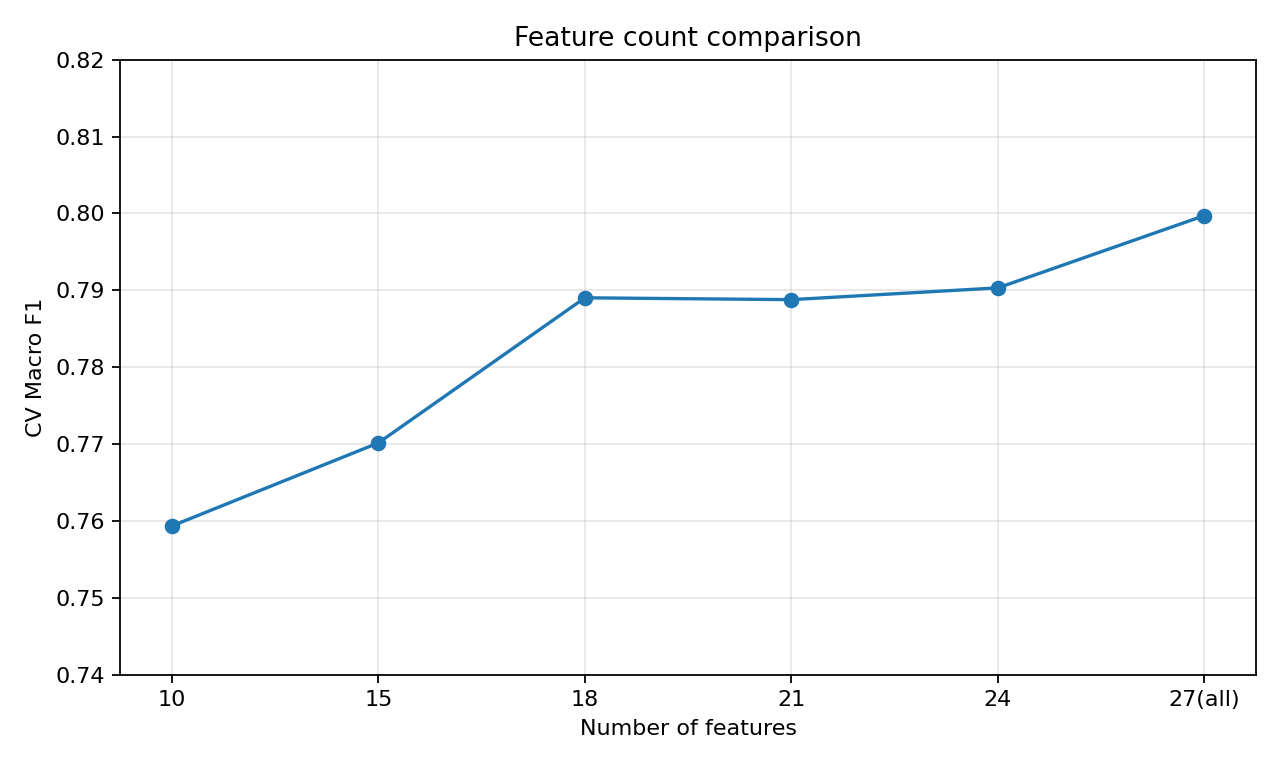

In [ ]:
# --------------------------------------------------
# 피처 수별 Macro F1 시각화
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    feature_count_resultDF['피처 수'],
    feature_count_resultDF['CV Macro F1'],
    marker='o'
)

plt.xlabel('Number of Features')
plt.ylabel('CV Macro F1')
plt.ylim(0.74, 0.82)
plt.title('Feature Count Comparison')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 피처 선택 결론

이번 실험에서는 10~24개로 피처를 줄였을 때보다 **전체 27개를 유지했을 때 교차검증 Macro F1이 가장 높았다.**

따라서 최종 피처 구성은 임의로 일부를 제거하지 않고 **전체 27개**로 결정한다. 이 결론은 테스트 점수가 아니라 학습 데이터 내부의 교차검증 결과를 기준으로 정했다.

**[9] 최종 선택 모델 평가**

In [ ]:
# --------------------------------------------------
# 최종 모델과 선택 피처 확인
# --------------------------------------------------
final_pipeline = searchModel.best_estimator_
selector = final_pipeline.named_steps['select']

selected_feature_columns = X.columns[selector.get_support()].tolist()

print(f'선택된 피처 수: {len(selected_feature_columns)}개')
print(selected_feature_columns)

# 최종 예측
y_train_pred = final_pipeline.predict(X_train)
y_pred = final_pipeline.predict(X_test)

선택된 피처 수: 27개
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']


In [ ]:
# --------------------------------------------------
# 최종 성능 계산
# --------------------------------------------------
final_scoreDF = pd.DataFrame({
    '평가지표': [
        'Train Accuracy', 'Test Accuracy',
        'Test Precision Macro', 'Test Recall Macro',
        'Test F1 Macro', 'Test F1 Weighted'
    ],
    '점수': [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro', zero_division=0),
        recall_score(y_test, y_pred, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='weighted')
    ]
})

display(final_scoreDF.round(4))

,평가지표,점수
0,Train Accuracy,0.9897
1,Test Accuracy,0.7995
2,Test Precision Macro,0.8558
3,Test Recall Macro,0.8016
4,Test F1 Macro,0.8264
5,Test F1 Weighted,0.8020


**[10] 결함 유형별 분류 성능**

In [ ]:
# --------------------------------------------------
# 분류 보고서
# --------------------------------------------------
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

classification_reportDF = pd.DataFrame(report_dict).T
display(classification_reportDF.round(4))

,precision,recall,f1-score,support
Bumps,0.7500,0.7407,0.7453,81.0000
Dirtiness,1.0000,0.9091,0.9524,11.0000
K_Scatch,0.9859,0.8974,0.9396,78.0000
Other_Faults,0.7171,0.8074,0.7596,135.0000
Pastry,0.5667,0.5312,0.5484,32.0000
Stains,1.0000,0.8571,0.9231,14.0000
Z_Scratch,0.9706,0.8684,0.9167,38.0000
accuracy,0.7995,0.7995,0.7995,0.7995
macro avg,0.8558,0.8016,0.8264,389.0000
weighted avg,0.8084,0.7995,0.8020,389.0000


### 결함별 해석

- `Dirtiness`, `K_Scatch`, `Stains`, `Z_Scratch`는 높은 F1을 기록했다.
- `Pastry`는 F1 약 0.55로 가장 낮아 여전히 `Other_Faults`와의 구분이 주요 개선 대상이다.
- 전체 피처를 추가하면서 기존 모델보다 대부분 클래스의 구분 성능이 개선됐다.

**[11] 혼동행렬**

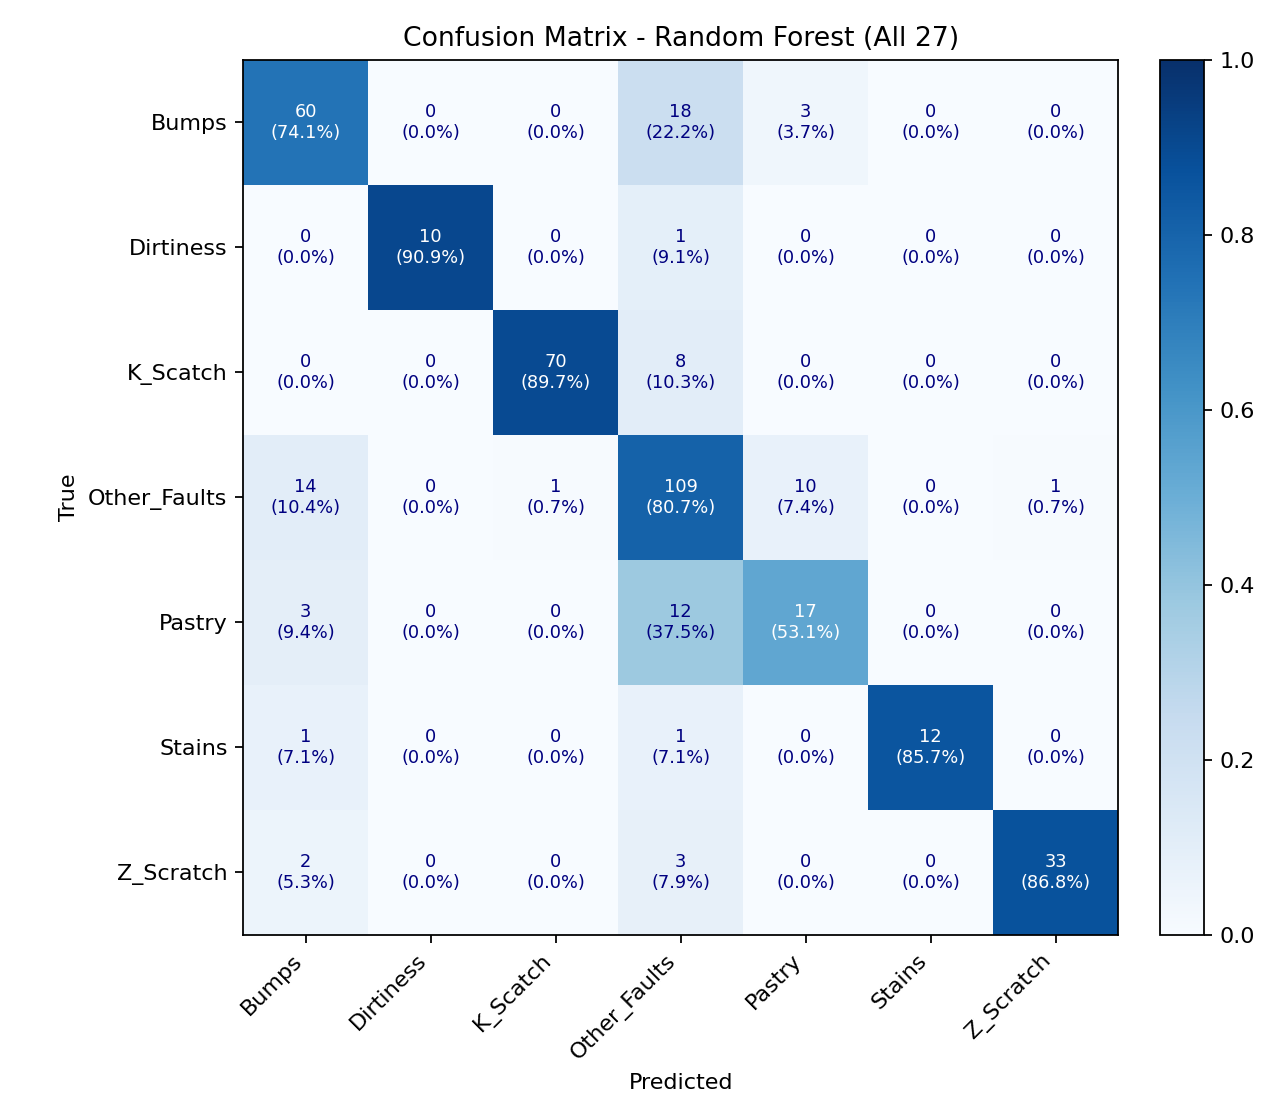

In [ ]:
# --------------------------------------------------
# 혼동행렬
# --------------------------------------------------
class_names = sorted(y.unique())
confusion = confusion_matrix(y_test, y_pred, labels=class_names)
row_sum = confusion.sum(axis=1, keepdims=True)

confusion_ratio = np.divide(
    confusion.astype(float),
    row_sum,
    out=np.zeros_like(confusion, dtype=float),
    where=row_sum != 0
)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(confusion_ratio, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

for row in range(len(class_names)):
    for column in range(len(class_names)):
        count = confusion[row, column]
        ratio = confusion_ratio[row, column]
        text_color = 'white' if ratio >= 0.5 else 'navy'

        ax.text(
            column, row,
            f'{count}\n({ratio:.1%})',
            ha='center', va='center',
            color=text_color,
            fontsize=9,
            fontweight='bold'
        )

ax.set_title('Confusion Matrix - Random Forest (All 27)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**[12] 최종 모델 피처 중요도**

In [ ]:
# --------------------------------------------------
# Random Forest 피처 중요도
# --------------------------------------------------
fitted_model = final_pipeline.named_steps['model']

feature_importanceDF = pd.DataFrame({
    'Feature': selected_feature_columns,
    'Importance': fitted_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

feature_importanceDF['Rank'] = feature_importanceDF.index + 1
feature_importanceDF = feature_importanceDF[
    ['Rank', 'Feature', 'Importance']
]

display(feature_importanceDF.head(15).round(4))

,Rank,Feature,Importance
0,1,LogOfAreas,0.0746
1,2,Length_of_Conveyer,0.0675
2,3,Pixels_Areas,0.0547
3,4,Outside_X_Index,0.0496
4,5,Sum_of_Luminosity,0.0473
5,6,Orientation_Index,0.0472
6,7,Minimum_of_Luminosity,0.0467
7,8,X_Minimum,0.0461
8,9,Log_X_Index,0.0405
9,10,Steel_Plate_Thickness,0.0400


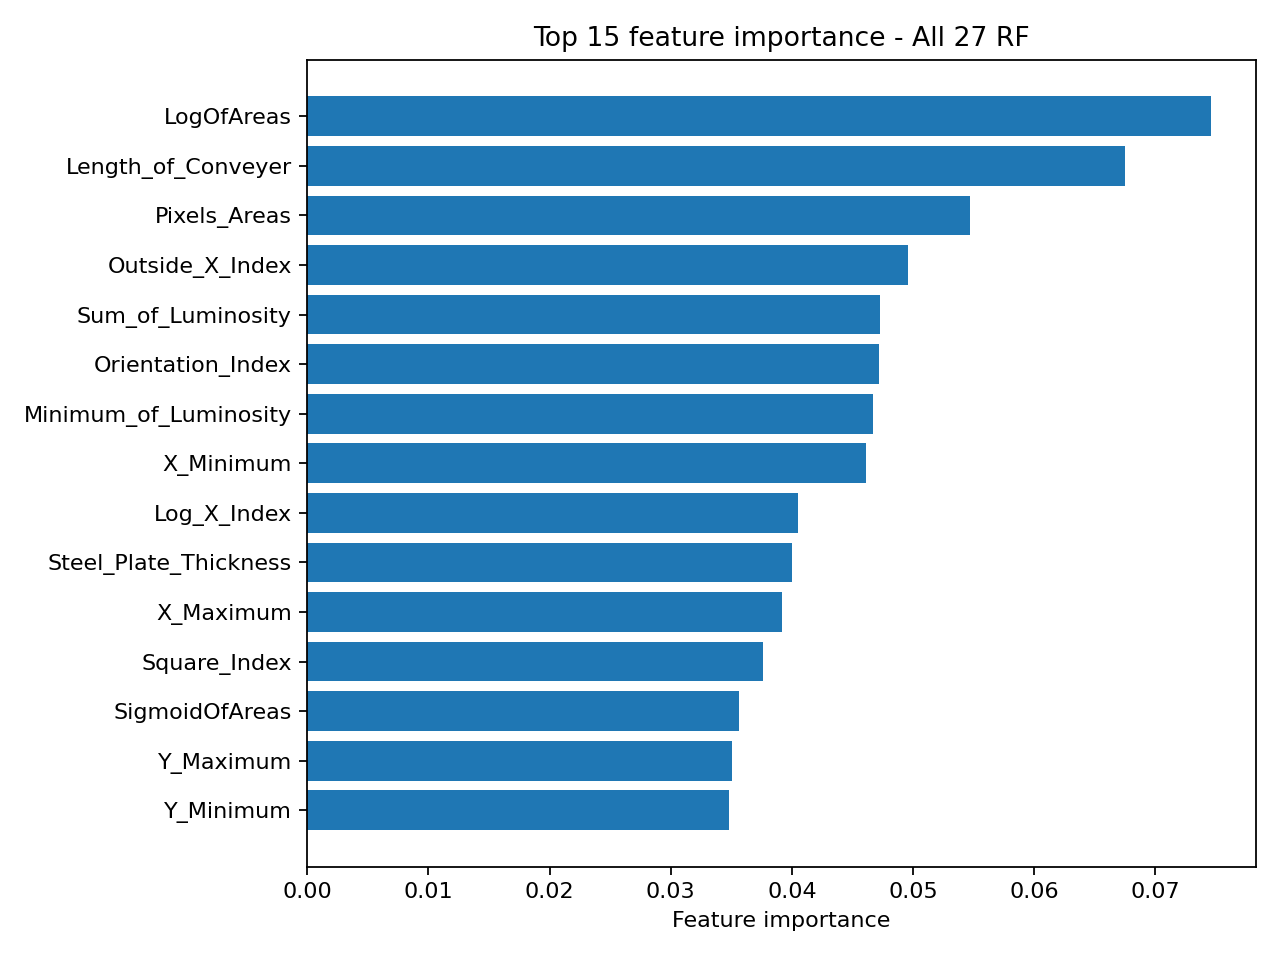

In [ ]:
# --------------------------------------------------
# 상위 15개 피처 중요도 시각화
# --------------------------------------------------
top_featureDF = feature_importanceDF.head(15).sort_values('Importance')

plt.figure(figsize=(9, 6))
plt.barh(top_featureDF['Feature'], top_featureDF['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance - All 27 RF')
plt.tight_layout()
plt.show()

## 최종 결론

1. 기존 13개 피처의 Test Macro F1은 약 **0.7548**이었다.
2. 전체 27개 피처를 사용했을 때 Test Macro F1은 약 **0.8264**로 상승했다.
3. 피처 수를 10~24개로 줄이는 실험보다 전체 27개 사용 시 교차검증 Macro F1이 가장 높았다.
4. 따라서 이번 데이터에서는 좌표, 밝기, 방향, 면적 관련 정보를 함께 사용하는 것이 결함 7종 분류에 유리했다.
5. 다만 Train Accuracy가 약 0.99로 높기 때문에 과적합 가능성은 남아 있으며, 이후에는 `max_depth`, `min_samples_leaf` 등을 추가 튜닝해 검증 성능과 학습 성능의 차이를 줄일 필요가 있다.

> 이 결과는 동일한 Train/Test 분할과 동일한 Random Forest 조건에서 피처 구성만 비교한 결과다.